In [58]:
import numpy as np

from reader import *
from encoder import *

bunny_model = Reader.read_from_file('assets/bunny.obj')

baseline_encoder = BaselineEncoder()
baseline_compressed_model = baseline_encoder.encode(bunny_model)

import matplotlib.pyplot as plt


def print_statistics(compressed_model, name):
    print(f"{name} statistics:")
    print(f"- Bytes per triangle: {compressed_model.bits_per_triangle / 8:.2f}")
    print(f"- Bytes per vertex: {compressed_model.bits_per_vertex / 8:.2f}")
    print(f"- Compression rate: {baseline_compressed_model.bits_per_vertex / compressed_model.bits_per_vertex:.2f}")


print_statistics(baseline_compressed_model, "BaselineEncoder")

BaselineEncoder statistics:
- Bytes per triangle: 18.05
- Bytes per vertex: 35.82
- Compression rate: 1.00


In [59]:
import pyvista as pv
import numpy as np

mesh = pv.read('assets/bunny.obj')

plotter = pv.Plotter()

# Add initial mesh actor (with faces visible)
actor = plotter.add_mesh(
    mesh,
    opacity=1.0,
    show_edges=False,
    color="lightsteelblue",
)

# Also add a "point cloud" actor for the same vertices—but hide it by default.
points_actor = plotter.add_points(
    mesh.points,
    color="tomato",
    point_size=5,
    render_points_as_spheres=True,
    opacity=1.0,
)
plotter.show(title="Interactive 3D Mesh Viewer", window_size=[800, 600])


Widget(value='<iframe src="http://localhost:56303/index.html?ui=P_0x19d341a2ad0_11&reconnect=auto" class="pyvi…

In [60]:
def generate_half_sphere_point_cloud(
        radius: float = 1.0,
        num_theta: int = 50,
        num_phi: int = 100
):
    """
    Generate a point cloud sampling the upper hemisphere (z >= 0) of a sphere.

    Parameters:
        radius   (float): Radius of the sphere.
        num_theta (int): Number of divisions from pole (z-axis) down to the equator (0 <= theta <= pi/2).
        num_phi   (int): Number of divisions around the azimuth (0 <= phi < 2*pi).

    Returns:
        vertices (list of [x, y, z]): A list of 3D coordinates on the hemisphere.
    """
    # theta ∈ [0, π/2] controls polar angle (0 = north pole, π/2 = equator)
    thetas = np.linspace(0, np.pi / 2, num_theta)
    # phi ∈ [0, 2π) controls azimuthal angle
    phis = np.linspace(0, 2 * np.pi, num_phi, endpoint=False)

    # Create a meshgrid of (theta, phi) pairs
    theta_grid, phi_grid = np.meshgrid(thetas, phis, indexing="ij")

    # Spherical → Cartesian conversion
    x = radius * np.sin(theta_grid) * np.cos(phi_grid)
    y = radius * np.sin(theta_grid) * np.sin(phi_grid)
    z = radius * np.cos(theta_grid)
    # z = np.zeros_like(y)

    # Flatten and zip into a list of [x, y, z]
    points = np.vstack((x.flatten(), y.flatten(), z.flatten())).T
    return points

In [61]:
half_sphere = generate_half_sphere_point_cloud(radius=1.0,
                                               num_theta=10,
                                               num_phi=25)

In [62]:
plotter = pv.Plotter()
points_actor = plotter.add_points(
    half_sphere,
    color="tomato",
    point_size=5,
    render_points_as_spheres=True,
    opacity=1.0,
)
plotter.show(title="Interactive 3D Mesh Viewer", window_size=[800, 600])

Widget(value='<iframe src="http://localhost:56303/index.html?ui=P_0x19ceaf86a90_12&reconnect=auto" class="pyvi…

In [63]:
def generate_circle_point_cloud(
        radius: float = 1.0,
        num_radial: int = 50,
        num_phi: int = 100
) -> list[list[float]]:
    """
    Generate a filled circle (disk) of points in the plane z = 0.

    Parameters:
        radius     (float): Radius of the circle.
        num_radial  (int): Number of concentric radial steps (from center to boundary).
        num_phi     (int): Number of angular divisions around each radial step.

    Returns:
        vertices (list of [x, y, z=0]): A list of 3D coordinates filling the disk of given radius.
    """
    # To achieve roughly uniform point density across the disk,
    # sample radii ∈ [0, radius] with sqrt spacing.
    radial_r = radius * np.sqrt(np.linspace(0, 1, num_radial))
    phis = np.linspace(0, 2 * np.pi, num_phi, endpoint=False)

    # Create a meshgrid of (r, φ) pairs
    r_grid, phi_grid = np.meshgrid(radial_r, phis, indexing="ij")

    # Polar → Cartesian conversion (z = 0 for all points)
    x = r_grid * np.cos(phi_grid)
    y = r_grid * np.sin(phi_grid)
    z = np.zeros_like(x)

    # Flatten and zip into a list of [x, y, 0]
    points = np.vstack((x.flatten(), y.flatten(), z.flatten())).T
    return points

In [64]:
circle = generate_circle_point_cloud(radius=1.0,
                                     num_radial=10,
                                     num_phi=25)

In [65]:
plotter = pv.Plotter()
points_actor = plotter.add_points(
    circle,
    color="tomato",
    point_size=5,
    render_points_as_spheres=True,
    opacity=1.0,
)
plotter.show(title="Interactive 3D Mesh Viewer", window_size=[800, 600])

Widget(value='<iframe src="http://localhost:56303/index.html?ui=P_0x19d3415f3d0_13&reconnect=auto" class="pyvi…

In [66]:
# 1) Generate the circle‐disk point cloud (z = 0 initially)
circle = generate_circle_point_cloud(radius=1.0, num_radial=15, num_phi=30)
circle_array = np.array(circle)  # shape: (N, 3)

# 2) Wrap these points in a PyVista PolyData
point_cloud = pv.PolyData(circle_array)

# 3) Create a Plotter and add the initial points actor
plotter = pv.Plotter()
points_actor = plotter.add_mesh(
    point_cloud,
    color="tomato",
    render_points_as_spheres=True,
    point_size=5,
    opacity=1.0,
    lighting=False,  # optional: disable lighting if you want flat‐color points
)


# 4) Define a callback that warps z = c * (x^2 + y^2)
def update_paraboloid(coefficient):
    """
    Slider callback to update the z‐coordinates of each point
    according to z = coefficient * (x^2 + y^2). Then re-render.
    """
    # Extract x and y (shape (N,))
    pts = point_cloud.points  # reference to underlying (N, 3) array
    x = pts[:, 0]
    y = pts[:, 1]

    # Compute new z
    new_z = -coefficient * (x ** 2 + y ** 2)

    # Overwrite the z‐column of the PolyData’s point array
    pts[:, 2] = new_z

    # Tell the Plotter to render the updated point positions
    plotter.render()


# 5) Add a slider widget to control the paraboloid coefficient 'c'
plotter.add_slider_widget(
    callback=update_paraboloid,
    rng=[-5.0, 5.0],  # you can adjust min/max of coefficient
    value=0.0,  # initial coefficient = 1.0
    title="Paraboloid Coefficient (c)",
    pointa=(0.025, 0.1),  # slider bar start (normalized x,y)
    pointb=(0.31, 0.1),  # slider bar end   (normalized x,y)
    style="modern",
)

# # 6) (Optional) Add text to indicate what the slider does
# plotter.add_text("Drag slider to warp circle into a paraboloid:\n"
#                  "z = c · (x² + y²)", position="upper_left", font_size=10)

# 7) Show the interactive window
plotter.show(title="Circle → Paraboloid Warping", window_size=[800, 600])

Widget(value='<iframe src="http://localhost:56303/index.html?ui=P_0x19ceafb19d0_14&reconnect=auto" class="pyvi…

In [67]:
import math


def compute_quantization_bits(
        vertices: np.ndarray,
        epsilon: float = 0.01
) -> tuple[int, int, float]:
    """
    Given an (N, 3) array of vertices and a maximum‐error fraction epsilon,
    compute:
      - B = the number of bits per coordinate needed so that
            max quantization error <= epsilon * (bounding cube side)
      - total_bits = 3 * B  (bits required per vertex)
      - side = bounding cube's side length

    We assume uniform quantization in each axis with 2^B levels, so:
      step size s = side / (2^B),
      max error = s/2 <= epsilon * side.
    Solving  (side/(2^B * 2)) <= epsilon * side  → 1/(2^(B+1)) <= epsilon
    → 2^(B+1) >= 1/epsilon  →  B >= log2(1/epsilon) − 1.
    """
    # 1) Compute the axis‐aligned bounding box, then its side length:
    mins = np.min(vertices, axis=0)  # (min_x, min_y, min_z)
    maxs = np.max(vertices, axis=0)  # (max_x, max_y, max_z)
    ranges = maxs - mins  # (range_x, range_y, range_z)
    side = float(np.max(ranges))  # bounding cube side

    # 2) Solve for B per the inequality:  2^(B+1) >= 1/epsilon
    B = math.ceil(math.log2(side / epsilon) - 1.0)

    # 3) Total bits per vertex (three coordinates)
    total_bits = 3 * B

    return B, total_bits, side

In [68]:
compute_quantization_bits(mesh.points)

(3, 9, 0.15515922000000001)

In [69]:
import numpy as np


def fit_sphere_to_points(points: np.ndarray) -> tuple[np.ndarray, float]:
    """
    Fit a sphere to an arbitrary set of 3D points (least-squares).

    This uses the linearization:
        x^2 + y^2 + z^2 + A x + B y + C z + D = 0
    Solve for [A, B, C, D] in least‐squares sense, then recover:
        center = (−A/2, −B/2, −C/2)
        radius = sqrt(center·center − D)

    Parameters:
        points (np.ndarray of shape (N, 3)): input vertices (x_i, y_i, z_i).

    Returns:
        center (np.ndarray of shape (3,)): the fitted sphere center (x0, y0, z0).
        radius (float): the fitted sphere radius.
    """
    # Build the linear system M · [A, B, C, D]^T = −(x^2 + y^2 + z^2)
    # where each row of M is [x_i, y_i, z_i, 1].
    X = points[:, 0]
    Y = points[:, 1]
    Z = points[:, 2]
    # Column vector of -(x^2 + y^2 + z^2)
    B_vec = -(X ** 2 + Y ** 2 + Z ** 2)

    # Build the design matrix M (shape N×4)
    M = np.column_stack((X, Y, Z, np.ones_like(X)))

    # Solve in least-squares sense: M·sol = B_vec
    sol, *_ = np.linalg.lstsq(M, B_vec, rcond=None)
    A, B, C, D = sol

    # Recover sphere center and radius
    center = np.array([-A / 2.0, -B / 2.0, -C / 2.0])
    radius_sq = center.dot(center) - D
    if radius_sq < 0:
        # Numerical issues can cause a tiny negative; clamp to zero if very small
        radius_sq = max(radius_sq, 0.0)
    radius = np.sqrt(radius_sq)

    return center, radius


def compute_sphere_residuals(
        points: np.ndarray,
        center: np.ndarray,
        radius: float
) -> np.ndarray:
    """
    Compute, for each point, the vector from that point to its closest point
    on the sphere of given center+radius. In other words:
        1) Translate each point so the sphere center is at the origin:
           p_c = p_i - center
        2) Find the closest point on the sphere surface:
           p_surf = (p_c / ||p_c||) * radius
           (If ||p_c|| is very small, we arbitrarily choose [radius, 0, 0].)
        3) The residual vector (from the original point to the sphere) is:
           residual_i = p_surf - p_c

    Residual_i has the same sign convention whether the point is inside
    (||p_c|| < radius) or outside (||p_c|| > radius):
      - If inside, p_surf is farther out → residual points outward.
      - If outside, p_surf is closer to origin → residual points inward.

    Parameters:
        points (np.ndarray of shape (N, 3)): input vertices.
        center (np.ndarray of shape (3, )): fitted sphere center.
        radius (float): fitted sphere radius.

    Returns:
        residuals (np.ndarray of shape (N, 3)): each row is the 3D vector
            that, when added to the centered point p_c, lands on the sphere.
    """
    # 1) Translate so center is at origin
    points_centered = points - center.reshape(1, 3)  # shape (N,3)

    # 2) Compute norms of each centered point
    norms = np.linalg.norm(points_centered, axis=1).reshape(-1, 1)  # shape (N,1)

    # 3) To avoid division by zero, define a tiny epsilon
    eps = 1e-12
    unit_dirs = np.zeros_like(points_centered)  # shape (N,3)

    # For points not at the center, unit_dir = p_c / ||p_c||
    nonzero_mask = norms.reshape(-1) > eps
    unit_dirs[nonzero_mask] = points_centered[nonzero_mask] / norms[nonzero_mask]

    # For any point extremely close to the center (norm ≈ 0), pick an arbitrary direction
    unit_dirs[~nonzero_mask] = np.array([1.0, 0.0, 0.0])  # e.g., +x direction

    # 4) Nearest points on the sphere surface (in centered coordinates)
    p_surf = unit_dirs * radius  # shape (N,3)

    # 5) Residual vector from each point to its projection on sphere:
    residuals = p_surf - points_centered  # shape (N,3)

    return residuals


In [15]:
center_fit, radius_fit = fit_sphere_to_points(mesh.points)
print("Fitted sphere center:", center_fit)
print("Fitted sphere radius:", radius_fit)

# 3) Compute signed residuals for each vertex
residuals = compute_sphere_residuals(mesh.points, center_fit, radius_fit)

Fitted sphere center: [-0.02286158  0.10070092  0.0015931 ]
Fitted sphere radius: 0.06657711189267701


In [16]:
def compute_quantization_bits_for_residuals(
        original_points: np.ndarray,
        residuals: np.ndarray,
        epsilon: float = 0.01
) -> tuple[int, int, float, float]:
    """
    Given:
      - original_points: (N,3) array
      - residuals:        (N,3) array of residual vectors = (p_surf − p_c)
      - epsilon:          fraction of the original side length (e.g., 0.01 for 1%)

    Returns:
      - B: bits per coordinate needed to quantize residuals so that
           max quantization error ≤ epsilon * (original_bounding_side).
      - total_bits: 3 * B  (bits per residual‐vector)
      - side_orig:   original bounding cube side length
      - side_res:    residuals bounding cube side length

    Derivation:
      Let side_orig = max_range(original_points)  (i.e. side of AABB).
      We want quantization error ≤ ε * side_orig. For uniform quantization in each axis:
         step_res = side_res / (2^B)
         max_err_axis = step_res / 2
         we require:  step_res/2 ≤ ε * side_orig
                  ⇒ side_res / (2^B * 2) ≤ ε * side_orig
                  ⇒ 2^(B+1) ≥ side_res / (ε * side_orig)
                  ⇒ B ≥ log2( side_res/(ε*side_orig) ) − 1

      If side_res/(ε*side_orig) < 1, then log2(…) − 1 < 0 ⇒ B ≤ 0 ⇒ we clamp B to 0.
    """
    # 1) Compute original bounding cube side
    mins_orig = np.min(original_points, axis=0)  # (min_x, min_y, min_z)
    maxs_orig = np.max(original_points, axis=0)  # (max_x, max_y, max_z)
    ranges_orig = maxs_orig - mins_orig  # (range_x, range_y, range_z)
    side_orig = float(np.max(ranges_orig))

    # 2) Compute residual‐cloud bounding cube side
    mins_res = np.min(residuals, axis=0)
    maxs_res = np.max(residuals, axis=0)
    ranges_res = maxs_res - mins_res
    side_res = float(np.max(ranges_res))

    ratio = side_res / (epsilon * side_orig)
    # 3) Solve for B (bits per coordinate)
    #    2^(B+1) ≥ side_res/(ε * side_orig)
    #    B ≥ log2(side_res/(ε * side_orig)) − 1
    if side_res <= 0 or side_orig <= 0:
        # degenerate: if either side is zero, no bits are needed
        B = 0
    else:
        ratio = side_res / (epsilon * side_orig)
        # If ratio ≤ 1, then log2(ratio)−1 ≤ −1 => B ≤ 0 ⇒ clamp to 0
        if ratio <= 1.0:
            B = 0
        else:
            B = math.ceil(math.log2(ratio) - 1.0)

    total_bits = 3 * B
    return B, total_bits, side_orig, side_res

In [17]:
B, total_bits, side_orig, side_res = compute_quantization_bits_for_residuals(
    original_points=mesh.points,
    residuals=residuals,
    # epsilon=epsilon
)

print(f"Original bounding‐cube side (side_orig) = {side_orig:.6f}")
print(f"Residuals bounding‐cube side (side_res) = {side_res:.6e}")
print(f"Bits per coordinate needed (B) = {B}")
print(f"Total bits per residual‐vector = {total_bits}")

Original bounding‐cube side (side_orig) = 0.155159
Residuals bounding‐cube side (side_res) = 7.372705e-02
Bits per coordinate needed (B) = 5
Total bits per residual‐vector = 15


In [18]:
original_model_bits_needed = math.ceil(math.log2(1 / 0.001))
original_model_bits_needed

10

In [19]:
total_bits_for_vertices_for_original = original_model_bits_needed * mesh.points.size
total_bits_for_vertices_for_original

75090

In [20]:
residual_model_bits_needed = math.ceil(math.log2(side_res / (side_orig * 0.001)))
residual_model_bits_needed

9

In [21]:
total_bits_for_vertices_for_residual = residual_model_bits_needed * mesh.points.size
total_bits_for_vertices_for_residual

67581

In [22]:
total_bits_for_vertices_for_original / total_bits_for_vertices_for_residual

1.1111111111111112

In [23]:
def generate_sphere_point_cloud(
        radius: float = 1.0,
        num_theta: int = 50,
        num_phi: int = 100
):
    """
    Generate a point cloud sampling the upper hemisphere (z >= 0) of a sphere.

    Parameters:
        radius   (float): Radius of the sphere.
        num_theta (int): Number of divisions from pole (z-axis) down to the equator (0 <= theta <= pi/2).
        num_phi   (int): Number of divisions around the azimuth (0 <= phi < 2*pi).

    Returns:
        vertices (list of [x, y, z]): A list of 3D coordinates on the hemisphere.
    """
    # theta ∈ [0, π/2] controls polar angle (0 = north pole, π/2 = equator)
    thetas = np.linspace(0, np.pi, num_theta)
    # phi ∈ [0, 2π) controls azimuthal angle
    phis = np.linspace(0, 2 * np.pi, num_phi, endpoint=False)

    # Create a meshgrid of (theta, phi) pairs
    theta_grid, phi_grid = np.meshgrid(thetas, phis, indexing="ij")

    # Spherical → Cartesian conversion
    x = radius * np.sin(theta_grid) * np.cos(phi_grid)
    y = radius * np.sin(theta_grid) * np.sin(phi_grid)
    z = radius * np.cos(theta_grid)
    # z = np.zeros_like(y)

    # Flatten and zip into a list of [x, y, z]
    points = np.vstack((x.flatten(), y.flatten(), z.flatten())).T
    return points

In [24]:
import pyvista as pv
import numpy as np

mesh = pv.read('assets/bunny.obj')

plotter = pv.Plotter()

# Add initial mesh actor (with faces visible)
actor = plotter.add_mesh(
    mesh,
    opacity=1.0,
    show_edges=False,
    color="lightsteelblue",
)

# Also add a "point cloud" actor for the same vertices—but hide it by default.
points_actor = plotter.add_points(
    mesh.points,
    color="tomato",
    point_size=5,
    render_points_as_spheres=True,
    opacity=1.0,
)

sphere_points_actor = plotter.add_points(
    generate_sphere_point_cloud(radius_fit, num_theta=50,
                                num_phi=50) + center_fit,
    color="green",
    point_size=5,
    render_points_as_spheres=True,
    opacity=1.0,
)

plotter.add_points(
    residuals,  # + center_fit,
    color="green",
    point_size=5,
    render_points_as_spheres=True,
    opacity=1.0,
)

plotter.show(title="Interactive 3D Mesh Viewer", window_size=[800, 600])


Widget(value='<iframe src="http://localhost:56303/index.html?ui=P_0x19d094a4b90_5&reconnect=auto" class="pyvis…

In [25]:
import pyvista as pv
import numpy as np

plotter = pv.Plotter()

plotter.add_points(
    residuals,
    color="green",
    point_size=5,
    render_points_as_spheres=True,
    opacity=1.0,
)

plotter.show(title="Interactive 3D Mesh Viewer", window_size=[800, 600])


Widget(value='<iframe src="http://localhost:56303/index.html?ui=P_0x19d15176290_6&reconnect=auto" class="pyvis…

In [26]:
import numpy as np
from scipy.optimize import least_squares


def fit_axis_aligned_ellipsoid(points: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """
    Fit an axis‐aligned ellipsoid to a set of 3D points in least‐squares sense.
    First try the algebraic SVD approach:
        A x^2 + B y^2 + C z^2 + D x + E y + F z + G = 0
    If that gives A <= 0 or B <= 0 or C <= 0, fall back to a nonlinear
    least‐squares parameterization in (x0,y0,z0,a,b,c).

    Returns:
        center (np.ndarray of shape (3,)): [x0, y0, z0]
        axes   (np.ndarray of shape (3,)): [a, b, c]  (all > 0)
    """
    # --- 1) Try the algebraic (SVD) fit ---
    X = points[:, 0]
    Y = points[:, 1]
    Z = points[:, 2]
    M = np.column_stack((X ** 2, Y ** 2, Z ** 2, X, Y, Z, np.ones_like(X)))  # (N×7)
    # Solve for the null‐space vector of M (smallest singular value):
    _, _, Vh = np.linalg.svd(M, full_matrices=False)
    A, B, C, D, E, F, G = Vh[-1, :]  # coefficients of the quadric

    # If A,B,C > 0, recover center & axes directly:
    if (A > 0) and (B > 0) and (C > 0):
        x0 = -D / (2.0 * A)
        y0 = -E / (2.0 * B)
        z0 = -F / (2.0 * C)
        center_alg = np.array([x0, y0, z0])

        a_alg = np.sqrt(1.0 / A)
        b_alg = np.sqrt(1.0 / B)
        c_alg = np.sqrt(1.0 / C)
        axes_alg = np.array([a_alg, b_alg, c_alg])

        # Sanity check: reject if any axis is not finite or <= 0
        if np.all(np.isfinite(axes_alg)) and np.all(axes_alg > 0):
            return center_alg, axes_alg

    # --- 2) Algebraic failed: fall back to nonlinear least‐squares fit ---
    return _fit_ellipsoid_nonlinear(points)


def _fit_ellipsoid_nonlinear(points: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """
    Solve for (x0, y0, z0, a, b, c) by minimizing:
        f_i = ( (x_i-x0)^2 / a^2 + (y_i-y0)^2 / b^2 + (z_i-z0)^2 / c^2  - 1 )
    in a least‐squares sense. We enforce a>0, b>0, c>0 via bounds.
    """
    # Initial guess: center ~ centroid, axes ~ half the bounding‐box extents
    centroid = np.mean(points, axis=0)
    mins = np.min(points, axis=0)
    maxs = np.max(points, axis=0)
    bbox_extents = maxs - mins
    # Guess a,b,c as half of the max axis extent (so points roughly lie within ±a, ±b, ±c)
    a0 = bbox_extents[0] / 2.0
    b0 = bbox_extents[1] / 2.0
    c0 = bbox_extents[2] / 2.0
    # Ensure none are zero:
    a0 = max(a0, 1e-3)
    b0 = max(b0, 1e-3)
    c0 = max(c0, 1e-3)

    x0, y0, z0 = centroid
    initial = np.array([x0, y0, z0, a0, b0, c0])  # length‐6 vector

    # Define the residuals function:
    def residuals_func(params):
        x0, y0, z0, a, b, c = params
        # Translate points
        xc = points[:, 0] - x0
        yc = points[:, 1] - y0
        zc = points[:, 2] - z0
        # We want (xc/a)^2 + (yc/b)^2 + (zc/c)^2 = 1
        # Residual per point i:
        return (xc / a) ** 2 + (yc / b) ** 2 + (zc / c) ** 2 - 1.0

    # Bounds: x0,y0,z0 free; a,b,c ∈ (eps, +∞). Use eps=1e-6 to keep them positive.
    eps = 1e-6
    lower = np.array([-np.inf, -np.inf, -np.inf, eps, eps, eps])
    upper = np.array([np.inf, np.inf, np.inf, np.inf, np.inf, np.inf])

    result = least_squares(
        residuals_func,
        initial,
        bounds=(lower, upper),
        xtol=1e-12,
        ftol=1e-12,
        gtol=1e-12,
        max_nfev=2000
    )

    x0_opt, y0_opt, z0_opt, a_opt, b_opt, c_opt = result.x
    center_nl = np.array([x0_opt, y0_opt, z0_opt])
    axes_nl = np.array([a_opt, b_opt, c_opt])
    return center_nl, axes_nl


def compute_ellipsoid_residuals(
        points: np.ndarray,
        center: np.ndarray,
        axes: np.ndarray
) -> np.ndarray:
    """
    Compute the radial residual vector from each point to its projection on
    the *axis‐aligned* ellipsoid (center, axes). This is the same as before:

      1) p_c = p_i − center
      2) denom_i = sqrt((x_c/a)^2 + (y_c/b)^2 + (z_c/c)^2). If denom ≈ 0, set t=1.
      3) t = 1 / denom_i
      4) p_surf = t * p_c
      5) residual_i = p_surf − p_c  = (t − 1) * p_c

    Returns:
      residuals: (N,3) array of 3D vectors.
    """
    pts_centered = points - center.reshape(1, 3)
    a, b, c = axes

    x_c = pts_centered[:, 0]
    y_c = pts_centered[:, 1]
    z_c = pts_centered[:, 2]
    denom = np.sqrt((x_c / a) ** 2 + (y_c / b) ** 2 + (z_c / c) ** 2).reshape(-1, 1)
    eps = 1e-12
    t = np.zeros_like(denom)
    nonzero_mask = (denom.reshape(-1) > eps)
    t[nonzero_mask] = 1.0 / denom[nonzero_mask]
    # For points at/near center, let t=1 so residual is zero:
    t[~nonzero_mask] = 1.0

    p_surf = pts_centered * t
    residuals = p_surf - pts_centered
    return residuals


In [27]:
vertices = mesh.points  # - mesh.points.min(axis=0)
center_fit, axes_fit = fit_axis_aligned_ellipsoid(vertices)
print("Fitted ellipsoid center:    ", center_fit)
print("Fitted semi‐axes lengths (a, b, c):", axes_fit)

# 3) Compute residual vectors to the ellipsoid surface
residuals = compute_ellipsoid_residuals(vertices, center_fit, axes_fit)

Fitted ellipsoid center:     [-0.01672969  0.11185274  0.00563333]
Fitted semi‐axes lengths (a, b, c): [0.07480823 0.09004108 0.05785793]


In [28]:
(mesh.points - mesh.points.min(axis=0)).min()

np.float64(0.0)

In [29]:
def generate_ellipsoid_point_cloud(
        center: np.ndarray,
        axes: np.ndarray,
        num_u: int = 50,
        num_v: int = 100
) -> np.ndarray:
    """
    Generate a point cloud sampling the surface of an axis-aligned ellipsoid.

    Parameters:
        center (np.ndarray of shape (3,)): [x0, y0, z0] = ellipsoid center.
        axes   (np.ndarray of shape (3,)): [a, b, c] = semi-axes lengths along x, y, z.
        num_u  (int): Number of latitude divisions (from 0 to π). Default = 50.
        num_v  (int): Number of longitude divisions (from 0 to 2π). Default = 100.

    Returns:
        pts (np.ndarray of shape (num_u * num_v, 3)):
            A list of [x, y, z] points on the ellipsoid surface.
    """
    x0, y0, z0 = center
    a, b, c = axes

    # Parameter ranges:
    #   u ∈ [0, π] (latitude)
    #   v ∈ [0, 2π) (longitude)
    us = np.linspace(0.0, np.pi, num_u)
    vs = np.linspace(0.0, 2.0 * np.pi, num_v, endpoint=False)

    # Construct a meshgrid of shape (num_u, num_v)
    u_grid, v_grid = np.meshgrid(us, vs, indexing="ij")

    # Parametric equations for an axis-aligned ellipsoid:
    #   x = x0 + a * sin(u) * cos(v)
    #   y = y0 + b * sin(u) * sin(v)
    #   z = z0 + c * cos(u)
    x_vals = x0 + a * np.sin(u_grid) * np.cos(v_grid)
    y_vals = y0 + b * np.sin(u_grid) * np.sin(v_grid)
    z_vals = z0 + c * np.cos(u_grid)

    # Flatten to a (N,3) array
    pts = np.vstack((x_vals.flatten(),
                     y_vals.flatten(),
                     z_vals.flatten())).T  # shape = (num_u*num_v, 3)

    return pts

In [30]:
import pyvista as pv
import numpy as np

mesh = pv.read('assets/bunny.obj')

plotter = pv.Plotter()

# Add initial mesh actor (with faces visible)
actor = plotter.add_mesh(
    mesh,
    opacity=1.0,
    show_edges=False,
    color="lightsteelblue",
)

# Also add a "point cloud" actor for the same vertices—but hide it by default.
points_actor = plotter.add_points(
    mesh.points,
    color="tomato",
    point_size=5,
    render_points_as_spheres=True,
    opacity=1.0,
)

sphere_points_actor = plotter.add_points(
    generate_ellipsoid_point_cloud(center_fit, axes_fit),
    color="green",
    point_size=5,
    render_points_as_spheres=True,
    opacity=1.0,
)

plotter.add_points(
    residuals,  # + center_fit,
    color="green",
    point_size=5,
    render_points_as_spheres=True,
    opacity=1.0,
)

plotter.show(title="Interactive 3D Mesh Viewer", window_size=[800, 600])


Widget(value='<iframe src="http://localhost:56303/index.html?ui=P_0x19d151b9a90_7&reconnect=auto" class="pyvis…

In [31]:
mins_res = np.min(residuals, axis=0)
maxs_res = np.max(residuals, axis=0)
ranges_res = maxs_res - mins_res
side_res = float(np.max(ranges_res))

residual_model_bits_needed = math.ceil(math.log2(side_res / (side_orig * 0.001)))
residual_model_bits_needed
total_bits_for_vertices_for_residual = residual_model_bits_needed * mesh.points.size
total_bits_for_vertices_for_residual
total_bits_for_vertices_for_original / total_bits_for_vertices_for_residual

1.0

In [32]:
residual_model_bits_needed

10

In [33]:
side_res

0.09396973198889531

In [34]:
side_orig

0.15515922000000001

In [35]:
import numpy as np
import trimesh
import torch
from tqdm import tqdm


def sample_sdf_on_mesh(
        mesh_path: str,
        N_surface: int = 50000,
        N_off_surface: int = 50000,
        N_bulk: int = 50000,
        max_offset: float = 0.1
) -> tuple[np.ndarray, np.ndarray]:
    """
    Given a mesh file, sample points and compute approximate SDF values.

    Returns:
      pts ( (N_total, 3) array ),
      sdf ( (N_total,) array )

    Strategy:
      1. Load mesh via trimesh.
      2. Sample N_surface points uniformly on faces (SDF=0).
      3. For each surface point+normal, sample two offset points at ±max_offset:
         - one inside (neg), one outside (pos)
      4. Uniformly sample N_bulk pts in bounding box, compute exact SDF by closest‐point query.
    """
    # 1) Load mesh
    mesh = trimesh.load(mesh_path, process=True)
    if not mesh.is_watertight:
        print("Warning: mesh is not watertight. SDF queries may be approximate.")
    # Ensure there are per‐vertex normals, or compute face normals & interpolate
    mesh.rezero()  # shift mesh so that bounding box is more centered

    # 2) Sample surface points
    surface_pts, face_indices = trimesh.sample.sample_surface(mesh, N_surface)
    # Get corresponding face normals and then vertex‐interpolated normals
    face_normals = mesh.face_normals[face_indices]  # (N_surface, 3)
    # For each surface_pt, approximate normal by face normal
    surface_normals = face_normals / np.linalg.norm(face_normals, axis=1, keepdims=True)

    # SDF=0 for these
    pts_surf = surface_pts.astype(np.float32)  # (N_surface, 3)
    sdf_surf = np.zeros((N_surface,), dtype=np.float32)  # (N_surface,)

    # 3) Generate off‐surface points along normals
    # We'll take a random offset between 0 and max_offset (so N_off_surface = N_surface too)
    # For simplicity, generate N_off_surface/2 inside and N_off_surface/2 outside.
    half = N_off_surface // 2
    indices = np.random.choice(N_surface, half, replace=False)
    offsets = np.random.uniform(0.0, max_offset, size=(half, 1)).astype(np.float32)

    # Outside points: p + offset * n  →  SDF = +offset
    pts_off_pos = surface_pts[indices] + offsets * surface_normals[indices]
    sdf_off_pos = offsets.reshape(-1).astype(np.float32)

    # Inside points: p - offset * n  →  SDF = -offset
    pts_off_neg = surface_pts[indices] - offsets * surface_normals[indices]
    sdf_off_neg = -offsets.reshape(-1).astype(np.float32)

    # Concatenate these
    pts_off = np.vstack((pts_off_pos, pts_off_neg)).astype(np.float32)  # (2*half, 3)
    sdf_off = np.concatenate((sdf_off_pos, sdf_off_neg))  # (2*half,)

    # 4) Bulk sampling: random points in the axis‐aligned bounding box
    # Compute axis‐aligned bounding box from mesh.vertices
    mins = mesh.bounds[0]  # (3,)
    maxs = mesh.bounds[1]  # (3,)
    # Expand a bit so network learns outside too
    pad = (maxs - mins) * 0.05
    lower = mins - pad
    upper = maxs + pad

    # Sample uniformly in [lower, upper]
    pts_bulk = np.random.uniform(lower, upper, size=(N_bulk, 3)).astype(np.float32)

    # 5) For bulk points, compute exact SDF via trimesh.proximity
    # trimesh.proximity.signed_distance needs a watertight mesh; if not, fallback to unsigned
    bulk_sdf = trimesh.proximity.signed_distance(mesh, pts_bulk)
    bulk_sdf = bulk_sdf.astype(np.float32)

    # 6) Concatenate all samples
    pts_all = np.vstack((pts_surf, pts_off, pts_bulk))  # (N_surface + 2*half + N_bulk, 3)
    sdf_all = np.concatenate((sdf_surf, sdf_off, bulk_sdf))  # (same length,)

    return pts_all, sdf_all


In [36]:
pts, sdf_vals = sample_sdf_on_mesh(
    "assets/torus.obj",
    N_surface=20000,
    N_off_surface=20000,
    N_bulk=40000,
    max_offset=0.05
)
print("Total samples:", pts.shape[0])
# pts: float32 array (N,3), sdf_vals: float32 array (N,)

Total samples: 80000


In [37]:
import torch
import torch.nn as nn


class DeepSDFNet(nn.Module):
    def __init__(self, width=256, depth=8):
        """
        width: number of hidden units per layer
        depth: number of hidden layers (not counting input+output)
        """
        super().__init__()
        self.depth = depth
        self.width = width

        # Input: (x, y, z) → 3 dims
        # Hidden: depth layers, each width dims
        # Output: 1 dim (signed distance)
        layers = []
        in_dim = 3
        for i in range(depth):
            layers.append(nn.Linear(in_dim, width))
            layers.append(nn.Softplus(beta=100))  # or nn.ReLU()
            in_dim = width
        layers.append(nn.Linear(width, 1))

        self.net = nn.Sequential(*layers)

        # Initialize weights (DeepSDF uses Xavier/Kaiming initialization)
        for m in self.net:
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight, gain=nn.init.calculate_gain('relu'))
                nn.init.zeros_(m.bias)

    def forward(self, x):
        # x: tensor shape (batch_size, 3)
        return self.net(x)  # returns (batch_size, 1)

In [38]:
model = DeepSDFNet(width=256, depth=8)
dummy = torch.rand((10, 3))
out = model(dummy)
print(out.shape)  # should be (10, 1)

torch.Size([10, 1])


In [39]:
def sdf_loss(pred_sdf, true_sdf, clamp=0.1):
    """
    Optionally clamp both predictions and truths to [-clamp, clamp]
    so that far‐away errors don’t dominate.
    """
    if clamp is not None:
        pred = torch.clamp(pred_sdf, -clamp, clamp)
        gt = torch.clamp(true_sdf, -clamp, clamp)
    else:
        pred = pred_sdf
        gt = true_sdf
    return torch.mean(torch.abs(pred - gt))


In [40]:
import torch
from torch.utils.data import TensorDataset, DataLoader


def train_deep_sdf(
        pts: np.ndarray,
        sdf_vals: np.ndarray,
        model: nn.Module,
        batch_size: int = 2048,
        lr: float = 1e-4,
        epochs: int = 500,
        clamp_dist: float = 0.1,
        l2_reg: float = 1e-6,
        device: str = 'cuda'
):
    """
    Train the MLP to regress SDF values on pts.

    - pts:   (N,3) float32 array  → input coordinates
    - sdf_vals: (N,) float32 array → ground‐truth SDF values
    - model: DeepSDFNet instance
    """
    model = model.to(device)
    # 1) Create dataset and dataloader
    tensor_pts = torch.from_numpy(pts).float()
    tensor_sdf = torch.from_numpy(sdf_vals).float().unsqueeze(1)  # (N,1)
    dataset = TensorDataset(tensor_pts, tensor_sdf)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=4, drop_last=True)

    # 2) Optimizer + (optional) weight decay on weights
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=l2_reg)

    for epoch in range(1, epochs + 1):
        total_loss = 0.0
        for batch_pts, batch_sdf in loader:
            batch_pts = batch_pts.to(device)
            batch_sdf = batch_sdf.to(device)

            optimizer.zero_grad()
            pred_sdf = model(batch_pts)  # (batch_size,1)
            loss = sdf_loss(pred_sdf, batch_sdf, clamp=clamp_dist)
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * batch_pts.shape[0]

        avg_loss = total_loss / len(dataset)
        #if epoch % 50 == 0 or epoch == 1:
        print(f"Epoch {epoch:4d}/{epochs:4d}   Loss = {avg_loss:.6f}")

    print("Training complete. Final loss:", avg_loss)
    return model

In [41]:
# 1) Prepare SDF samples
pts, sdf_vals = sample_sdf_on_mesh(
    "assets/torus.obj",
    N_surface=3000,
    N_off_surface=3000,
    N_bulk=6000,
    max_offset=0.05
)

# 2) Create DeepSDF network
net = DeepSDFNet(width=256, depth=8)

# 3) Train on GPU (if available)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
net = train_deep_sdf(
    pts, sdf_vals, net,
    batch_size=4096,
    lr=1e-4,
    epochs=50,
    clamp_dist=0.05,
    l2_reg=1e-6,
    device=device
)

Epoch    1/  50   Loss = 0.029406
Epoch    2/  50   Loss = 0.027325
Epoch    3/  50   Loss = 0.027031
Epoch    4/  50   Loss = 0.027019
Epoch    5/  50   Loss = 0.027032
Epoch    6/  50   Loss = 0.027375
Epoch    7/  50   Loss = 0.027201
Epoch    8/  50   Loss = 0.027141
Epoch    9/  50   Loss = 0.027281
Epoch   10/  50   Loss = 0.027549
Epoch   11/  50   Loss = 0.026977
Epoch   12/  50   Loss = 0.027462
Epoch   13/  50   Loss = 0.027238
Epoch   14/  50   Loss = 0.027484
Epoch   15/  50   Loss = 0.027454
Epoch   16/  50   Loss = 0.027143
Epoch   17/  50   Loss = 0.027383
Epoch   18/  50   Loss = 0.027289
Epoch   19/  50   Loss = 0.027439
Epoch   20/  50   Loss = 0.027259
Epoch   21/  50   Loss = 0.027468
Epoch   22/  50   Loss = 0.027332
Epoch   23/  50   Loss = 0.027174
Epoch   24/  50   Loss = 0.027142
Epoch   25/  50   Loss = 0.027254
Epoch   26/  50   Loss = 0.027305
Epoch   27/  50   Loss = 0.027325
Epoch   28/  50   Loss = 0.027429
Epoch   29/  50   Loss = 0.027105
Epoch   30/  5

In [42]:
import pyvista as pv


def reconstruct_mesh_from_sdf(
        model: nn.Module,
        lower: np.ndarray,
        upper: np.ndarray,
        resolution: int = 128,
        device: str = 'cuda'
) -> pv.PolyData:
    """
    Reconstruct a triangular mesh by evaluating the trained SDF on a 3D grid
    and running marching cubes (isosurface at 0).

    - model: trained DeepSDF network
    - lower, upper: (3,) arrays giving bounding box for sampling
    - resolution: grid resolution per axis (e.g. 128)
    """
    model = model.to(device)
    model.eval()

    # Create uniform grid coordinates
    xs = np.linspace(lower[0], upper[0], resolution)
    ys = np.linspace(lower[1], upper[1], resolution)
    zs = np.linspace(lower[2], upper[2], resolution)
    # We will batch‐evaluate slices to save memory
    sdf_values = np.zeros((resolution, resolution, resolution), dtype=np.float32)

    with torch.no_grad():
        for i, x in enumerate(xs):
            # Build a meshgrid of shape (resolution^2, 3) for (y,z) at this x
            Y, Z = np.meshgrid(ys, zs, indexing='ij')
            YZ = np.stack((Y.flatten(), Z.flatten()), axis=1)  # (res^2, 2)
            Xs = np.full((resolution * resolution, 1), x, dtype=np.float32)  # (res^2, 1)
            pts_batch = np.hstack((Xs, YZ)).astype(np.float32)  # (res^2, 3)
            pts_torch = torch.from_numpy(pts_batch).to(device)

            sdf_pred = model(pts_torch).cpu().numpy().reshape(resolution, resolution)
            sdf_values[i, :, :] = sdf_pred

    # # Create a PyVista UniformGrid to hold the SDF volume
    # grid = pv.ImageData()
    # grid.dimensions = (resolution, resolution, resolution)
    # grid.origin = tuple(lower.tolist())
    # spacing = ((upper - lower) / (resolution - 1)).tolist()
    # grid.spacing = tuple(spacing)
    #
    # # 5) Assign SDF as POINT data (length must be resolution^3)
    # #    PyVista expects a flat array of length resolution^3 in Fortran order
    # grid.point_data["sdf"] = sdf_values.flatten(order="F")
    #
    # # 6) Extract the zero‐isosurface
    # mesh = grid.contour([0.0], scalars="sdf")
    # return mesh

    grid = pv.ImageData()
    grid.dimensions = np.array(sdf_values.shape) + 1  # +1 for cell data
    grid.origin = tuple(lower.tolist())
    spacing = ((upper - lower) / (resolution - 1)).tolist()
    grid.spacing = tuple(spacing)
    # Cell‐centered data; flatten to 1D
    grid.cell_data["sdf"] = sdf_values.flatten(order="F")

    grid.plot(show_edges=True)
    # Extract the zero isosurface
    # mesh = grid.contour([0.0], scalars="sdf")
    # return mesh

In [43]:
# Determine bounding box from the original mesh
import trimesh

mesh = trimesh.load("assets/torus.obj", process=True)
mins = mesh.bounds[0] - 0.05  # pad by 5 cm if your object is ~1 m
maxs = mesh.bounds[1] + 0.05

reconstructed = reconstruct_mesh_from_sdf(
    net,  # trained network
    lower=mins.astype(np.float32),
    upper=maxs.astype(np.float32),
    resolution=128,
    device=device
)

# # Visualize in PyVista
# pv_plotter = pv.Plotter()
# pv_plotter.add_mesh(mesh, style="wireframe", color="black", opacity=0.3)
# pv_plotter.add_mesh(reconstructed, color="cyan", opacity=0.8)
# pv_plotter.show()


Widget(value='<iframe src="http://localhost:56303/index.html?ui=P_0x19d33da7a10_8&reconnect=auto" class="pyvis…

In [44]:
from geomdl import fitting  # Fitting routines
from geomdl.visualization import VisMPL  # Matplotlib‐based visualizer
from geomdl import BSpline, utilities  # Core classes and utilities
import numpy as np

In [45]:
def generate_ellipsoid_grid(center, axes, num_u=30, num_v=60):
    """
    Create a [num_u][num_v] grid of points on an axis‐aligned ellipsoid.

    Args:
        center: array‐like of length 3 → (x0, y0, z0)
        axes:   array‐like of length 3 → (a, b, c)
        num_u:  number of latitude samples (0 ≤ u ≤ π)
        num_v:  number of longitude samples (0 ≤ v < 2π)

    Returns:
        pts_grid: a list of length num_u, each element is a list of length num_v of (x,y,z).
    """
    x0, y0, z0 = center
    a, b, c = axes

    # Parameter ranges
    us = np.linspace(0.0, np.pi, num_u)
    vs = np.linspace(0.0, 2.0 * np.pi, num_v, endpoint=False)

    pts_grid = []
    for u in us:
        row = []
        sin_u = np.sin(u)
        cos_u = np.cos(u)
        for v in vs:
            cos_v = np.cos(v)
            sin_v = np.sin(v)
            x = x0 + a * sin_u * cos_v
            y = y0 + b * sin_u * sin_v
            z = z0 + c * cos_u
            pts_grid.append((float(x), float(y), float(z)))
        # pts_grid.append(row)

    return pts_grid


# Example: sample an ellipsoid centered at (0.2, -0.1, 0.5) with axes (1.5, 0.8, 0.5)
center_example = np.array([0.2, -0.1, 0.5])
axes_example = np.array([1.5, 0.8, 0.5])

num_u = 30
num_v = 60
pts_grid = generate_ellipsoid_grid(center_example, axes_example, num_u=num_u, num_v=num_v)
print(f"Generated a grid of {len(pts_grid)}×{len(pts_grid[0])} = {len(pts_grid) * len(pts_grid[0])} points.")


Generated a grid of 1800×3 = 5400 points.


In [46]:
degree_u = 2
degree_v = 2

# For a smooth, “global” fit, choose control grid smaller than sample grid:
size_u = 5  # must be > degree_u
size_v = 10  # must be > degree_v


In [47]:
len(pts_grid)

1800

In [48]:
# `pts_grid` is our [num_u][num_v] list of surface samples.
surf = fitting.approximate_surface(pts_grid,
                                   size_u, size_v,
                                   degree_u, degree_v)


ZeroDivisionError: float division by zero

In [49]:
max_err = 0.0
for i in range(len(pts_grid)):
    for j in range(len(pts_grid[0])):
        u = i / (len(pts_grid) - 1)  # parameter uniform in [0,1]
        v = j / (len(pts_grid[0]) - 1)
        pt_surf = surf.evaluate_single([u, v])  # returns [x,y,z]
        pt_data = np.array(pts_grid[i][j])
        err = np.linalg.norm(pt_surf - pt_data)
        max_err = max(max_err, err)
print("Maximum fitting error:", max_err)


NameError: name 'surf' is not defined

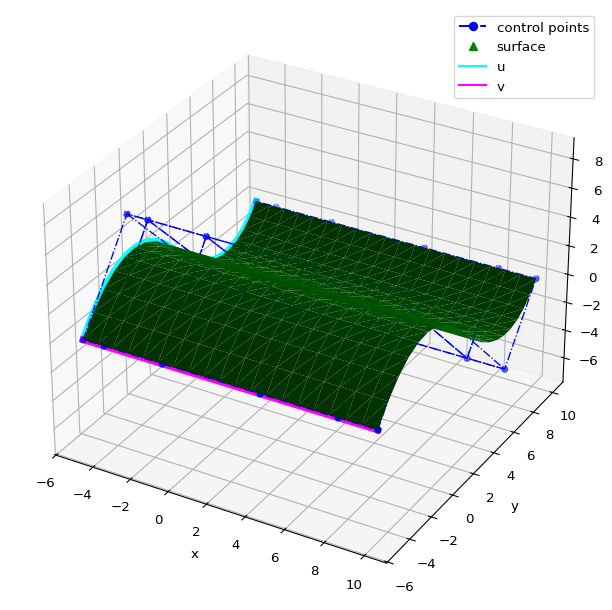

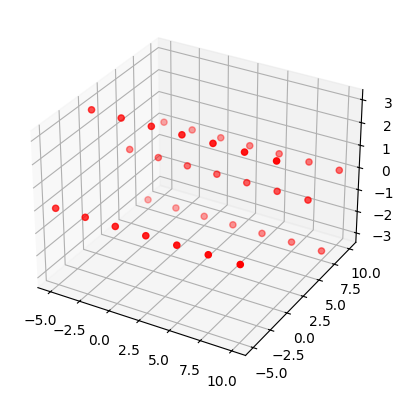

In [50]:
from geomdl import construct
from geomdl import fitting
from geomdl.visualization import VisMPL as vis

# Data set
points = ((-5, -5, 0), (-2.5, -5, 0), (0, -5, 0), (2.5, -5, 0), (5, -5, 0), (7.5, -5, 0), (10, -5, 0),
          (-5, 0, 3), (-2.5, 0, 3), (0, 0, 3), (2.5, 0, 3), (5, 0, 3), (7.5, 0, 3), (10, 0, 3),
          (-5, 5, 0), (-2.5, 5, 0), (0, 5, 0), (2.5, 5, 0), (5, 5, 0), (7.5, 5, 0), (10, 5, 0),
          (-5, 7.5, -3), (-2.5, 7.5, -3), (0, 7.5, -3), (2.5, 7.5, -3), (5, 7.5, -3), (7.5, 7.5, -3), (10, 7.5, -3),
          (-5, 10, 0), (-2.5, 10, 0), (0, 10, 0), (2.5, 10, 0), (5, 10, 0), (7.5, 10, 0), (10, 10, 0))
size_u = 5
size_v = 7
degree_u = 2
degree_v = 3

# Do global surface approximation
surf = fitting.approximate_surface(points, size_u, size_v, degree_u, degree_v)
# surf = fitting.approximate_surface(points, size_u, size_v, degree_u, degree_v, ctrlpts_size_u=3, ctrlpts_size_v=4)

# Extract curves from the approximated surface
surf_curves = construct.extract_curves(surf)
plot_extras = [
    dict(
        points=surf_curves['u'][0].evalpts,
        name="u",
        color="cyan",
        size=5
    ),
    dict(
        points=surf_curves['v'][0].evalpts,
        name="v",
        color="magenta",
        size=5
    )
]

# Plot the interpolated surface
surf.delta = 0.05
surf.vis = vis.VisSurface()
surf.render(extras=plot_extras)

# Visualize data and evaluated points together
import numpy as np
import matplotlib.pyplot as plt

evalpts = np.array(surf.evalpts)
pts = np.array(points)
fig = plt.figure()
ax = plt.axes(projection='3d')
# ax.scatter(evalpts[:, 0], evalpts[:, 1], evalpts[:, 2])
ax.scatter(pts[:, 0], pts[:, 1], pts[:, 2], color="red")
plt.show()

In [51]:
pts.shape

(35, 3)

In [70]:
import numpy as np
from scipy.optimize import least_squares

# def fit_axis_aligned_ellipsoid_nonlinear(points: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
#     """
#     Nonlinearly fit an axis‐aligned ellipsoid to arbitrary 3D points by optimizing
#     (x0, y0, z0, a, b, c) to minimize ∑[( (x_i-x0)/a )^2 + ((y_i-y0)/b)^2 + ((z_i-z0)/c)^2 − 1]^2.
#
#     Returns:
#         center (np.ndarray of shape (3,)): fitted (x0, y0, z0)
#         axes   (np.ndarray of shape (3,)): fitted (a, b, c) > 0
#     """
#     # Initial guess: centroid for center, half‐ranges for axes
#     centroid = np.mean(points, axis=0)
#     mins = np.min(points, axis=0)
#     maxs = np.max(points, axis=0)
#     half_extents = (maxs - mins) / 2.0
#     # Avoid zero:
#     a0, b0, c0 = np.maximum(half_extents, 1e-3)
#     initial = np.array([centroid[0], centroid[1], centroid[2], a0, b0, c0])
#
#     def residuals(params):
#         x0, y0, z0, a, b, c = params
#         # Enforce a,b,c > 0 by returning large residual if negative
#         if a <= 0 or b <= 0 or c <= 0:
#             return 1e6 * np.ones(points.shape[0])
#         xc = (points[:, 0] - x0) / a
#         yc = (points[:, 1] - y0) / b
#         zc = (points[:, 2] - z0) / c
#         return xc**2 + yc**2 + zc**2 - 1.0
#
#     # Bounds: center free, axes > 0
#     lower = np.array([-np.inf, -np.inf, -np.inf, 1e-6, 1e-6, 1e-6])
#     upper = np.array([ np.inf,  np.inf,  np.inf,  np.inf,  np.inf,  np.inf])
#
#     result = least_squares(
#         residuals,
#         initial,
#         bounds=(lower, upper),
#         xtol=1e-12,
#         ftol=1e-12,
#         gtol=1e-12,
#         max_nfev=2000
#     )
#
#     x0_opt, y0_opt, z0_opt, a_opt, b_opt, c_opt = result.x
#     return np.array([x0_opt, y0_opt, z0_opt]), np.array([a_opt, b_opt, c_opt])
#
from tqdm import tqdm, trange


def fit_axis_aligned_ellipsoid_nn(
        points: np.ndarray,
        num_iters: int = 1000,
        lr: float = 1e-2,
        device: str = "cpu"
) -> tuple[np.ndarray, np.ndarray]:
    """
    Fit an axis‐aligned ellipsoid to `points` by treating (x0,y0,z0,a,b,c) as
    learnable parameters in PyTorch and minimizing ∑[( (x−x0)/a )^2 + ((y−y0)/b)^2 + ((z−z0)/c)^2 − 1 ]^2
    via gradient descent.

    Returns:
        center: np.ndarray of shape (3,)  -- learned [x0, y0, z0]
        axes:   np.ndarray of shape (3,)  -- learned [a, b, c] (all > 0)
    """
    # Convert points to torch tensor on the chosen device
    pts = torch.from_numpy(points.astype(np.float32)).to(device)  # (N,3)

    # Initialize parameters:
    # center (x0,y0,z0) = centroid of points
    centroid = points.mean(axis=0).astype(np.float32)
    # axes (a,b,c) = half‐ranges in x,y,z
    mins = points.min(axis=0).astype(np.float32)
    maxs = points.max(axis=0).astype(np.float32)
    half_extents = ((maxs - mins) / 2.0).astype(np.float32)
    # Prevent zero initial axes:
    a0, b0, c0 = np.maximum(half_extents, 1e-3)

    # Create torch parameters with requires_grad=True
    x0 = torch.tensor(centroid[0], requires_grad=True, dtype=torch.float32, device=device)
    y0 = torch.tensor(centroid[1], requires_grad=True, dtype=torch.float32, device=device)
    z0 = torch.tensor(centroid[2], requires_grad=True, dtype=torch.float32, device=device)
    # To enforce positivity of a,b,c, we parametrize them via softplus of unconstrained variables:
    sa = torch.tensor(np.log(np.exp(a0) - 1.0), requires_grad=True, dtype=torch.float32, device=device)
    sb = torch.tensor(np.log(np.exp(b0) - 1.0), requires_grad=True, dtype=torch.float32, device=device)
    sc = torch.tensor(np.log(np.exp(c0) - 1.0), requires_grad=True, dtype=torch.float32, device=device)

    # Build optimizer over all parameters
    optimizer = torch.optim.Adam([x0, y0, z0, sa, sb, sc], lr=lr)

    for it in trange(num_iters):
        optimizer.zero_grad()

        # Recover actual a,b,c via softplus to keep them > 0
        a = torch.nn.functional.softplus(sa)
        b = torch.nn.functional.softplus(sb)
        c = torch.nn.functional.softplus(sc)

        # Center points
        xc = (pts[:, 0] - x0) / a
        yc = (pts[:, 1] - y0) / b
        zc = (pts[:, 2] - z0) / c

        # Ellipsoid residual: f_i = xc^2 + yc^2 + zc^2 - 1
        f = xc * xc + yc * yc + zc * zc - 1.0  # (N,)

        # Loss = mean squared residual
        loss = torch.mean(f * f)

        loss.backward()
        optimizer.step()

        # Optional: print every 200 iterations
        if (it + 1) % 200 == 0 or it == 0:
            with torch.no_grad():
                print(f"Iter {it + 1}/{num_iters}, Loss = {loss.item():.6e}, "
                      f"a={a.item():.4f}, b={b.item():.4f}, c={c.item():.4f}")

    # After optimization, extract final center and axes
    with torch.no_grad():
        center = torch.stack((x0, y0, z0)).cpu().numpy()
        a = torch.nn.functional.softplus(sa).cpu().numpy()
        b = torch.nn.functional.softplus(sb).cpu().numpy()
        c = torch.nn.functional.softplus(sc).cpu().numpy()
        axes = np.array([a, b, c], dtype=np.float32)

    return center, axes


def compute_ellipsoid_residuals(
        points: np.ndarray,
        center: np.ndarray,
        axes: np.ndarray
) -> np.ndarray:
    """
    For each point p, compute the vector residual to the fitted ellipsoid:
      1) p_c = p − center
      2) denom = sqrt((x_c/a)^2 + (y_c/b)^2 + (z_c/c)^2)
         if denom > ε: t = 1/denom else t = 1
      3) p_surf = t * p_c
      4) residual = p_surf − p_c
    Returns array of shape (N,3).
    """
    pts_c = points - center.reshape(1, 3)
    a, b, c = axes
    x_c = pts_c[:, 0]
    y_c = pts_c[:, 1]
    z_c = pts_c[:, 2]

    denom = np.sqrt((x_c / a) ** 2 + (y_c / b) ** 2 + (z_c / c) ** 2).reshape(-1, 1)
    eps = 1e-12
    t = np.zeros_like(denom)
    nonzero = (denom.reshape(-1) > eps)
    t[nonzero] = 1.0 / denom[nonzero]
    t[~nonzero] = 1.0

    p_surf = pts_c * t
    residuals = p_surf - pts_c
    return residuals


def split_points_along_longest_axis(
        points: np.ndarray,
        center: np.ndarray,
        axes: np.ndarray
) -> tuple[np.ndarray, np.ndarray]:
    """
    Split `points` into two subsets along the ellipsoid’s longest axis:
      1) idx = argmax(axes)
      2) split_val = center[idx]
      3) pts0: points[:,idx] < split_val; pts1: points[:,idx] >= split_val
    """
    idx = np.argmax(axes)
    # split_val = center[idx]
    # split_val = center[idx]
    coord = points[:, idx]
    split_val = (coord.max() + coord.min()) / 2.0
    mask0 = coord < split_val
    return points[mask0], points[~mask0]


class EllipsoidNode:
    """
    Node for hierarchical ellipsoid fit.
    Attributes:
      center:   (3,) fitted center
      axes:     (3,) fitted semi‐axes
      residuals:(N_subset, 3) residual vectors
      points:   (N_subset, 3) original subset
      children: [] or [child0, child1]
    """

    def __init__(self, center, axes, residuals, points):
        self.center = center
        self.axes = axes
        self.residuals = residuals
        self.points = points
        self.children = []


def fit_ellipsoids_hierarchical_nonlinear(
        points: np.ndarray,
        max_depth: int = 3
) -> EllipsoidNode:
    """
    Hierarchically fit ellipsoids to `points` up to `max_depth` levels,
    using nonlinear least‐squares at each node.

    Returns the root EllipsoidNode.
    """

    def recurse(sub_pts: np.ndarray, depth: int) -> EllipsoidNode:
        # 1) Nonlinear ellipsoid fit
        center, axes = fit_axis_aligned_ellipsoid_nn(sub_pts, num_iters=2000)
        # 2) Compute residuals
        residuals = compute_ellipsoid_residuals(sub_pts, center, axes)
        node = EllipsoidNode(center, axes, residuals, sub_pts)

        # 3) Split if not at max depth
        if depth < max_depth and sub_pts.shape[0] > 10:
            pts0, pts1 = split_points_along_longest_axis(residuals, center, axes)
            if pts0.shape[0] > 0 and pts1.shape[0] > 0:
                child0 = recurse(pts0, depth + 1)
                child1 = recurse(pts1, depth + 1)
                node.children = [child0, child1]
        return node

    return recurse(points, depth=1)


# Generate a noisy half‐sphere point cloud (arbitrary data)
def generate_noisy_half_sphere(
        radius: float = 1.0,
        num_theta: int = 60,
        num_phi: int = 120,
        noise_sigma: float = 0.02
) -> np.ndarray:
    """
    Sample a hemisphere plus Gaussian noise to simulate arbitrary shape data.
    """
    thetas = np.linspace(0, np.pi / 2, num_theta)
    phis = np.linspace(0, 2 * np.pi, num_phi, endpoint=False)
    theta_grid, phi_grid = np.meshgrid(thetas, phis, indexing="ij")
    x = radius * np.sin(theta_grid) * np.cos(phi_grid)
    y = radius * np.sin(theta_grid) * np.sin(phi_grid)
    z = radius * np.cos(theta_grid)
    pts = np.vstack((x.flatten(), y.flatten(), z.flatten())).T
    pts += np.random.normal(scale=noise_sigma, size=pts.shape)
    return pts


pts = generate_noisy_half_sphere(radius=1.0, num_theta=60, num_phi=120, noise_sigma=0.2)

# Fit hierarchical ellipsoids nonlinearly to depth=3
root = fit_ellipsoids_hierarchical_nonlinear(mesh.points, max_depth=3)


# Traverse and print the hierarchy
def print_tree(node: EllipsoidNode, indent: int = 0):
    prefix = "  " * indent
    N = node.points.shape[0]
    print(f"{prefix}Depth {indent + 1}: {N} points")
    print(f"{prefix}  Center: {node.center}")
    print(f"{prefix}  Axes:   {node.axes}")
    if node.children:
        for child in node.children:
            print_tree(child, indent + 1)


print_tree(root)

  8%|▊         | 165/2000 [00:00<00:01, 1589.84it/s]

Iter 1/2000, Loss = 1.991733e-01, a=0.0776, b=0.0768, c=0.0602
Iter 200/2000, Loss = 1.648100e-01, a=0.0748, b=0.0900, c=0.0579


 28%|██▊       | 551/2000 [00:00<00:00, 1678.59it/s]

Iter 400/2000, Loss = 1.648101e-01, a=0.0748, b=0.0900, c=0.0579
Iter 600/2000, Loss = 1.648779e-01, a=0.0749, b=0.0900, c=0.0579


 53%|█████▎    | 1066/2000 [00:00<00:00, 1701.54it/s]

...

Iter 1200/2000, Loss = 1.694278e-01, a=0.0019, b=0.0174, c=0.0017
Iter 1400/2000, Loss = 1.666327e-01, a=0.0019, b=0.0179, c=0.0017


 92%|█████████▏| 1841/2000 [00:01<00:00, 1743.79it/s]

Iter 1600/2000, Loss = 1.639195e-01, a=0.0019, b=0.0184, c=0.0017
Iter 1800/2000, Loss = 1.613059e-01, a=0.0019, b=0.0189, c=0.0017


100%|██████████| 2000/2000 [00:01<00:00, 1768.96it/s]

Iter 2000/2000, Loss = 1.587924e-01, a=0.0019, b=0.0195, c=0.0017
Depth 1: 2503 points
  Center: [-0.01672935  0.11185285  0.00563331]
  Axes:   [0.07480845 0.09004109 0.05785789]
  Depth 2: 2388 points
    Center: [ 0.43765223  0.00582646 -0.00387318]
    Axes:   [0.4428409  0.08960713 0.11782835]
    Depth 3: 1566 points
      Center: [-0.0184013   0.00082831 -0.00018294]
      Axes:   [0.0239238  0.00115262 0.0012529 ]
    Depth 3: 822 points
      Center: [ 0.02904875  0.00015647 -0.00223255]
      Axes:   [0.0322136  0.00174292 0.00310107]
  Depth 2: 115 points
    Center: [-0.00849965  0.3430542   0.0021123 ]
    Axes:   [0.18174198 0.3142138  0.15304407]
    Depth 3: 7 points
      Center: [ 0.00054432 -0.02831286 -0.00035711]
      Axes:   [0.00318292 0.01824316 0.00216916]
    Depth 3: 108 points
      Center: [-0.00049605 -0.00178144  0.00136743]
      Axes:   [0.00188192 0.01951451 0.00170746]


In [71]:
pts

array([[ 0.14195734, -0.03915581,  1.26080526],
       [-0.29632086, -0.15377436,  1.397835  ],
       [-0.33289451, -0.08481339,  1.2818959 ],
       ...,
       [ 0.80150025, -0.05512817, -0.09060027],
       [ 0.73335755,  0.07154797,  0.0182364 ],
       [ 1.03322154, -0.12011527,  0.08120963]])

In [72]:
plotter = pv.Plotter()

# Also add a "point cloud" actor for the same vertices—but hide it by default.
points_actor = plotter.add_points(
    mesh.points,
    color="tomato",
    point_size=5,
    render_points_as_spheres=True,
    opacity=1.0,
)

plotter.add_points(
    generate_ellipsoid_point_cloud(root.center, root.axes),
    color="green",
    point_size=5,
    render_points_as_spheres=True,
    opacity=1.0,
)
points_actor = plotter.add_points(
    root.residuals,
    color="blue",
    point_size=5,
    render_points_as_spheres=True,
    opacity=1.0,
)

plotter.show(title="Interactive 3D Mesh Viewer", window_size=[800, 600])


Widget(value='<iframe src="http://localhost:56303/index.html?ui=P_0x19d35dae250_15&reconnect=auto" class="pyvi…

In [73]:
len(root.children[1].points)

115

In [74]:
plotter = pv.Plotter()

# points_actor = plotter.add_points(
#     root.points,
#     color="blue",
#     point_size=5,
#     render_points_as_spheres=True,
#     opacity=1.0,
# )
node = root.children[0]
# Also add a "point cloud" actor for the same vertices—but hide it by default.
points_actor = plotter.add_points(
    node.points,
    color="tomato",
    point_size=5,
    render_points_as_spheres=True,
    opacity=1.0,
)

plotter.add_points(
    generate_ellipsoid_point_cloud(node.center, node.axes),
    color="green",
    point_size=5,
    render_points_as_spheres=True,
    opacity=1.0,
)

plotter.show(title="Interactive 3D Mesh Viewer", window_size=[800, 600])


Widget(value='<iframe src="http://localhost:56303/index.html?ui=P_0x19ceb02b990_16&reconnect=auto" class="pyvi…

In [75]:
root.axes

array([0.07480845, 0.09004109, 0.05785789], dtype=float32)

In [76]:
root.children

In [77]:
parts = [root.children[0].children[0], root.children[0].children[1], root.children[1].children[0],
         root.children[1].children[1]]

for part in parts:
    residuals = part.residuals
    mins_res = np.min(residuals, axis=0)
    maxs_res = np.max(residuals, axis=0)
    ranges_res = maxs_res - mins_res
    print(ranges_res)
    side_res = float(np.max(ranges_res))


    residual_model_bits_needed = math.ceil(math.log2(side_res / (side_orig * 0.0005)))
    # residual_model_bits_needed
    print("residual_model_bits_needed: ", residual_model_bits_needed)
    total_bits_for_vertices_for_residual = residual_model_bits_needed * mesh.points.size
    # total_bits_for_vertices_for_residual
    # total_bits_for_vertices_for_original / total_bits_for_vertices_for_residual

[0.00964958 0.00061512 0.00052767]
residual_model_bits_needed:  7
[0.0179743  0.00149906 0.00344748]
residual_model_bits_needed:  8
[0.00029657 0.00072742 0.00016645]
residual_model_bits_needed:  4
[0.00102778 0.01119655 0.00153197]
residual_model_bits_needed:  8


In [78]:
side_orig

0.15515922000000001

In [79]:
len(mesh.points)

2503

In [80]:
2503 * 2

5006

In [81]:
2503 * 11 * 3

82599

In [82]:
2503 * 32 * 3

240288

In [83]:
2503 * 9 * 3 + 7 * 6 * 32

68925

In [84]:
original_model_bits_needed = math.ceil(math.log2(1 / 0.0005))
original_model_bits_needed

11

In [85]:
def get_tree_leafs(root: EllipsoidNode, leafs: list[EllipsoidNode]):
   is_leaf = len(root.children) == 0

   if is_leaf:
       leafs.append(root)
   else:
       for child in root.children:
           get_tree_leafs(child, leafs)

In [86]:
leafs = []
get_tree_leafs(root, leafs)

In [87]:
leafs

In [88]:
leafs

In [89]:
leafs[0].residuals.min(axis=0)

pyvista_ndarray([-0.0050764 , -0.00040183, -0.00037949])